# Data Tools and Exploratory Analysis

This notebook increases complexity in a controlled way: load a table, clean it, describe it, summarize it, and then create a chart that answers a business question.


## Inspecting a DataFrame

Students should learn to ask what each row represents and what each column means before computing summary statistics.


In [1]:
import pandas as pd

df = pd.DataFrame({
    'order_id': [1001, 1002, 1003, 1004],
    'region': ['North', ' south ', None, 'East'],
    'category': ['Books', 'Books', 'Home', 'Home'],
    'quantity': [2, 1, 3, 2],
    'unit_price': [12.0, 20.0, 8.0, 15.0],
    'rating': [5, 4, None, 3],
})
print(df.head())
print(df.isna().sum().to_dict())
assert df.shape == (4, 6)


   order_id   region category  quantity  unit_price  rating
0      1001    North    Books         2        12.0     5.0
1      1002   south     Books         1        20.0     4.0
2      1003     None     Home         3         8.0     NaN
3      1004     East     Home         2        15.0     3.0
{'order_id': 0, 'region': 1, 'category': 0, 'quantity': 0, 'unit_price': 0, 'rating': 1}


## Data cleaning logic

A missing value is not a zero. A whitespace issue is not a different category. Cleaning should follow the business meaning, not a blind shortcut.


In [2]:
df2 = df.copy()
df2['region'] = df2['region'].str.strip().str.title()
df2['region'] = df2['region'].fillna('Unknown')
df2['rating'] = df2['rating'].fillna(df2['rating'].median())
df2['revenue'] = df2['quantity'] * df2['unit_price']
print(df2[['region', 'revenue', 'rating']])
assert set(df2['region']) == {'North', 'South', 'Unknown', 'East'}


    region  revenue  rating
0    North     24.0     5.0
1    South     20.0     4.0
2  Unknown     24.0     4.0
3     East     30.0     3.0


## Aggregation and grouping

Groupby is one of the most important tools in data analysis because it turns row-level data into decision-level insight.


In [3]:
summary = df2.groupby('category').agg(
    order_count=('order_id', 'count'),
    total_revenue=('revenue', 'sum'),
    avg_rating=('rating', 'mean'),
).reset_index()
print(summary)
assert summary['order_count'].sum() == len(df2)


  category  order_count  total_revenue  avg_rating
0    Books            2           44.0         4.5
1     Home            2           54.0         3.5


## Visualizing the result

Charts communicate patterns, but only if they have clear labels and a clear question behind them.


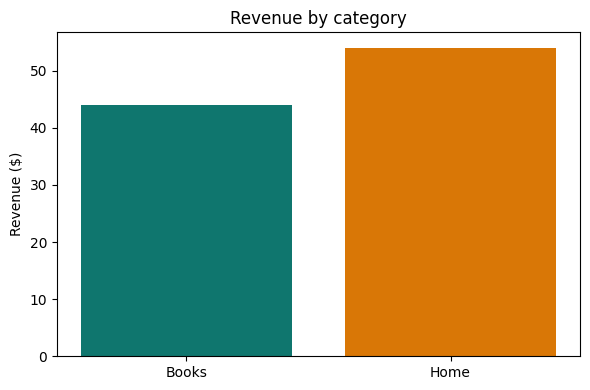

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(summary['category'], summary['total_revenue'], color=['#0f766e', '#d97706'])
plt.ylabel('Revenue ($)')
plt.title('Revenue by category')
plt.tight_layout()


## Short dataset exercise

The data is intentionally small enough to reason about by hand, but large enough to display a meaningful pattern. This is a good transition into the machine learning notebooks.


In [5]:
region_revenue = df2.groupby('region')['revenue'].sum().sort_values(ascending=False)
print(region_revenue)
assert round(region_revenue.sum(), 2) == round(df2['revenue'].sum(), 2)


region
East       30.0
North      24.0
Unknown    24.0
South      20.0
Name: revenue, dtype: float64
